# 1

In [1]:
# Defining project paths
BASE_DIR = "D:/Capstone/capstone_repo"
DATA_DIR = f"{BASE_DIR}/data"
NB_DIR = f"{BASE_DIR}/notebooks"
ANALYSIS_OUTPUT_DIR = f"{DATA_DIR}/analysis_output"
import os
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(ANALYSIS_OUTPUT_DIR, exist_ok=True)

In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt

In [3]:
districts = gpd.read_file(f"{DATA_DIR}/raw/gadm/gadm41_MAR_4.shp") 
districts.head()

,GID_4,GID_0,COUNTRY,GID_1,NAME_1,GID_2,NAME_2,GID_3,NAME_3,NAME_4,VARNAME_4,TYPE_4,ENGTYPE_4,CC_4,geometry
0,MAR.1.1.1.1_1,MAR,Morocco,MAR.1_1,Chaouia - Ouardigha,MAR.1.1_1,Ben Slimane,MAR.1.1.1_1,Ben Slimane,Ahlaf,NA,Commune Rural,Rural Commune,NA,"POLYGON ((-7.21601 33.33524, -7.20212 33.34536..."
1,MAR.1.1.1.2_1,MAR,Morocco,MAR.1_1,Chaouia - Ouardigha,MAR.1.1_1,Ben Slimane,MAR.1.1.1_1,Ben Slimane,Ain Tizgha,NA,Commune Rural,Rural Commune,NA,"POLYGON ((-7.01937 33.57966, -7.02208 33.57954..."
2,MAR.1.1.1.3_1,MAR,Morocco,MAR.1_1,Chaouia - Ouardigha,MAR.1.1_1,Ben Slimane,MAR.1.1.1_1,Ben Slimane,Fdalate,NA,Commune Rural,Rural Commune,NA,"POLYGON ((-7.25532 33.68698, -7.24397 33.66458..."
3,MAR.1.1.1.4_1,MAR,Morocco,MAR.1_1,Chaouia - Ouardigha,MAR.1.1_1,Ben Slimane,MAR.1.1.1_1,Ben Slimane,Mellila,NA,Commune Rural,Rural Commune,NA,"POLYGON ((-6.96569 33.36103, -6.96891 33.35316..."
4,MAR.1.1.1.5_1,MAR,Morocco,MAR.1_1,Chaouia - Ouardigha,MAR.1.1_1,Ben Slimane,MAR.1.1.1_1,Ben Slimane,Moualine El Ghaba,NA,Commune Rural,Rural Commune,NA,"POLYGON ((-7.12737 33.72615, -7.1226 33.71605,..."


In [4]:
casablanca_districts = districts[districts['NAME_2'].str.contains("Casablanca", case=False, na=False)]

In [5]:
casablanca_districts = casablanca_districts.to_crs(epsg=4326)


In [6]:
casablanca_districts.head()

,GID_4,GID_0,COUNTRY,GID_1,NAME_1,GID_2,NAME_2,GID_3,NAME_3,NAME_4,VARNAME_4,TYPE_4,ENGTYPE_4,CC_4,geometry
346,MAR.5.1.1.1_1,MAR,Morocco,MAR.5_1,Grand Casablanca,MAR.5.1_1,Casablanca,MAR.5.1.1_1,Bouskoura,Bouskoura,NA,Commune Rural,Rural Commune,NA,"POLYGON ((-7.68792 33.41272, -7.68806 33.41307..."
347,MAR.5.1.1.2_1,MAR,Morocco,MAR.5_1,Grand Casablanca,MAR.5.1_1,Casablanca,MAR.5.1.1_1,Bouskoura,Dar Bouazza,NA,Commune Rural,Rural Commune,NA,"POLYGON ((-7.76684 33.45884, -7.77442 33.45698..."
348,MAR.5.1.2.1_1,MAR,Morocco,MAR.5_1,Grand Casablanca,MAR.5.1_1,Casablanca,MAR.5.1.2_1,Mediouna,El Majjatia Oulad Taleb,NA,Commune Rural,Rural Commune,NA,"POLYGON ((-7.52672 33.40465, -7.52772 33.40506..."
349,MAR.5.1.2.2_1,MAR,Morocco,MAR.5_1,Grand Casablanca,MAR.5.1_1,Casablanca,MAR.5.1.2_1,Mediouna,Lahraouyine,NA,Commune Rural,Rural Commune,NA,"POLYGON ((-7.4977 33.50524, -7.50182 33.5069, ..."
350,MAR.5.1.3.1_1,MAR,Morocco,MAR.5_1,Grand Casablanca,MAR.5.1_1,Casablanca,MAR.5.1.3_1,NA (Ahl Laghlam),Ahl Laghlam,NA,Commune Urbaine,Urban Commune,NA,"POLYGON ((-7.49482 33.55348, -7.50156 33.55503..."


In [7]:
casablanca_districts["NAME_3"].unique()

array(['Bouskoura', 'Mediouna', 'NA (Ahl Laghlam)', 'NA (Ain Chock)',
       'NA (Ain Harrouda)', 'NA (Ain Sebaa)', 'NA (Al Fida)',
       'NA (Al Idrissia)', 'NA (Anfa)', 'NA (Assoukhour Assawda)',
       'NA (Ben Msick)', 'NA (Bou Chentouf)', 'NA (El Maarif)',
       'NA (Hay Hassani)', 'NA (Hay Mohammadi)', 'NA (Lissasfa)',
       'NA (Machouar Casablanca)', 'NA (Mediouna)', 'NA (Mers Sultan)',
       'NA (Moulay Rachid)', 'NA (Moulay Youssef)', 'NA (Nouaceur)',
       'NA (Salmia)', 'NA (Sbata)', 'NA (Sidi Belyout)',
       'NA (Sidi Bernoussi)', 'NA (Sidi Maarouf)', 'NA (Sidi Moumen)',
       'NA (Sidi Othmane)', 'NA (Tit Mellil)', 'Tit Mellil'], dtype=object)

(-7.921518683499957, -7.335075496499965, 33.30175915310017, 33.690462586900104)

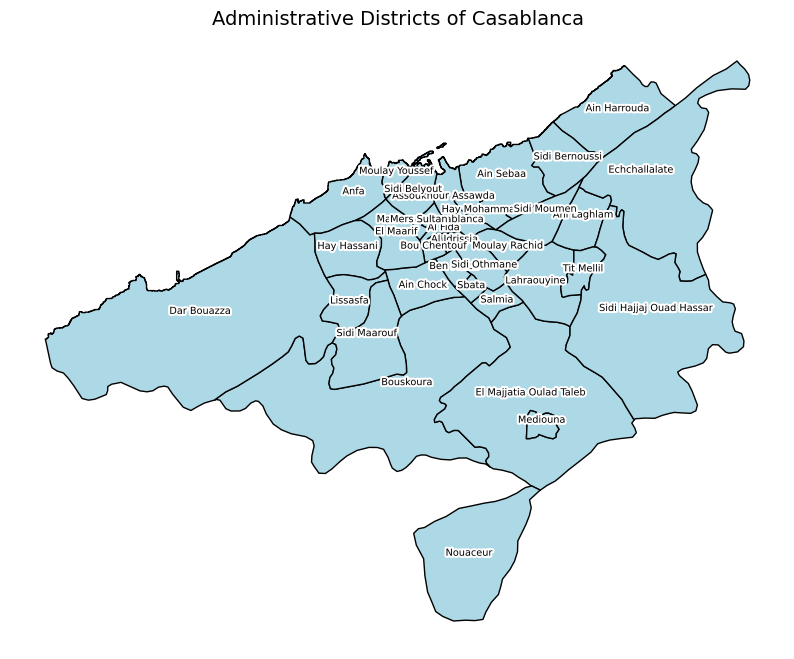

In [8]:
import matplotlib.patheffects as pe

casablanca_districts["label_point"] = casablanca_districts.geometry.representative_point()

fig, ax = plt.subplots(figsize=(10,10))
casablanca_districts.plot(ax=ax, edgecolor='black', facecolor='lightblue')

for idx, row in casablanca_districts.iterrows():
    ax.annotate(
        row["NAME_4"],
        xy=(row.label_point.x, row.label_point.y),
        ha='center',
        fontsize=7,
        color='black',
        path_effects=[pe.withStroke(linewidth=3, foreground="white")]
    )

ax.set_title("Administrative Districts of Casablanca", fontsize=14)
ax.axis('off')

Text(0.5, 1.0, 'Districts of Casablanca')

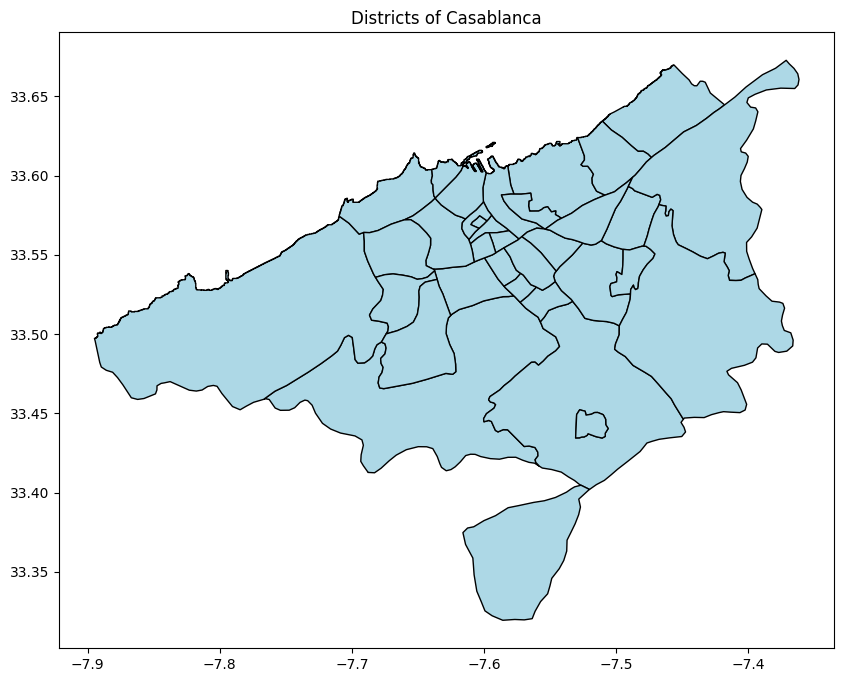

In [ ]:
casablanca_districts.plot(figsize=(10,10), edgecolor='black', facecolor='lightblue')
plt.savefig(f'{ANALYSIS_OUTPUT_DIR}/CasablancaDistricts.png', bbox_inches='tight')
plt.title("Districts of Casablanca")

In [11]:
import xml.etree.ElementTree as ET
import geopandas as gpd

tree = ET.parse(f"{DATA_DIR}/raw/Data/GC_Rep.qgs")
root = tree.getroot()

layers = []

for layer in root.iter("maplayer"):
    name = layer.find("layername").text
    source = layer.find("datasource").text
    layers.append((name, source))


In [12]:
for name, path in layers:
    print(name, path)

GC_Communes ./output /maps/GC_Communes/GC_Communes.shp
District-ref ./output /maps/District-ref-geocoded/District-ref.shp
GC_Communes_revised ./output /maps/GC_Communes_revised /GC_Communes_revised.shp
GC_repository ./output /maps/GC_repository/GC_repository.shp
GC_repository ./output /Table/GC_repository.csv
GC_Prefecture_Provinces ./input  /MAR_adm/MAR_adm3.shp|layerid=0|subset="NAME_2"='Casablanca'  OR  "NAME_2" = 'El Jadida'   OR   "NAME_2" = 'Settat'   OR   "NAME_2"='Ben Slimane'   OR  "NAME_2"='Mohammedia'
MAR_Communes ./input  /MAR_adm/MAR_adm4.shp


In [21]:
base_output = f"{DATA_DIR}/raw/Data/output"
base_input = f"{DATA_DIR}/raw/Data/input"

layers = {
    "GC_Communes": os.path.join(base_output, "maps/GC_Communes/GC_Communes.shp"),
    "District_ref": os.path.join(base_output, "maps/District-ref-geocoded/District-ref.shp"),
    "GC_Communes_revised": os.path.join(base_output, "maps/GC_Communes_revised/GC_Communes_revised.shp"),
    "GC_repository_shp": os.path.join(base_output, "maps/GC_repository/GC_repository.shp"),
    "GC_repository_csv": os.path.join(base_output, "Table/GC_repository.csv"),
}

gdf_communes = gpd.read_file(layers["GC_Communes_revised"])

In [26]:
gdf_communes[gdf_communes["NAME_2"] == "Casablanca"]

,ID_0,ISO,NAME_0,ID_1,NAME_1,ID_2,NAME_2,ID_3,NAME_3,ID_4,NAME_4,VARNAME_4,TYPE_4,ENGTYPE_4,VALIDFR_4,VALIDTO_4,REMARKS_4,Shape_Leng,Shape_Area,geometry
91,138,MAR,Morocco,1749,Grand Casablanca,20079,Casablanca,38442,NA (Sidi Maarouf),20978,Sidi Maarouf,None,Commune Urbaine,Urban Commune,Unknown,Present,None,0.222253,0.002355,"POLYGON ((-7.62141 33.47624, -7.62379 33.47465..."
153,138,MAR,Morocco,1749,Grand Casablanca,20079,Casablanca,38424,NA (Anfa),20960,Anfa,None,Commune Urbaine,Urban Commune,Unknown,Present,None,0.232886,0.001761,"POLYGON ((-7.70958 33.57439, -7.70958 33.57439..."
154,138,MAR,Morocco,1749,Grand Casablanca,20079,Casablanca,38425,NA (Assoukhour Assawda),20961,Assoukhour Assawda,None,Commune Urbaine,Urban Commune,Unknown,Present,None,0.194542,0.000840,"POLYGON ((-7.59819 33.60181, -7.59819 33.60153..."
155,138,MAR,Morocco,1749,Grand Casablanca,20079,Casablanca,38426,NA (Ben Msick),20962,Ben Msick,None,Commune Urbaine,Urban Commune,Unknown,Present,None,0.075307,0.000332,"POLYGON ((-7.57611 33.53471, -7.58489 33.53019..."
156,138,MAR,Morocco,1749,Grand Casablanca,20079,Casablanca,38427,NA (Bou Chentouf),20963,Bou Chentouf,None,Commune Urbaine,Urban Commune,Unknown,Present,None,0.058925,0.000223,"POLYGON ((-7.60711 33.54567, -7.60751 33.54551..."
157,138,MAR,Morocco,1749,Grand Casablanca,20079,Casablanca,38428,NA (El Maarif),20964,El Maarif,None,Commune Urbaine,Urban Commune,Unknown,Present,None,0.164429,0.001239,"POLYGON ((-7.61408 33.57264, -7.61648 33.57029..."
158,138,MAR,Morocco,1749,Grand Casablanca,20079,Casablanca,38429,NA (Hay Hassani),20965,Hay Hassani,None,Commune Urbaine,Urban Commune,Unknown,Present,None,0.158937,0.001490,"POLYGON ((-7.64963 33.56905, -7.64357 33.56383..."
159,138,MAR,Morocco,1749,Grand Casablanca,20079,Casablanca,38430,NA (Hay Mohammadi),20966,Hay Mohammadi,None,Commune Urbaine,Urban Commune,Unknown,Present,None,0.119565,0.000439,"POLYGON ((-7.56474 33.58895, -7.56391 33.5846,..."
161,138,MAR,Morocco,1749,Grand Casablanca,20079,Casablanca,38419,NA (Ain Chock),20955,Ain Chock,None,Commune Urbaine,Urban Commune,Unknown,Present,None,0.153846,0.001157,"POLYGON ((-7.62461 33.51241, -7.6253 33.51177,..."
162,138,MAR,Morocco,1749,Grand Casablanca,20079,Casablanca,38421,NA (Ain Sebaa),20957,Ain Sebaa,None,Commune Urbaine,Urban Commune,Unknown,Present,None,0.247850,0.002187,"POLYGON ((-7.58153 33.60625, -7.58153 33.60625..."


<Axes: >

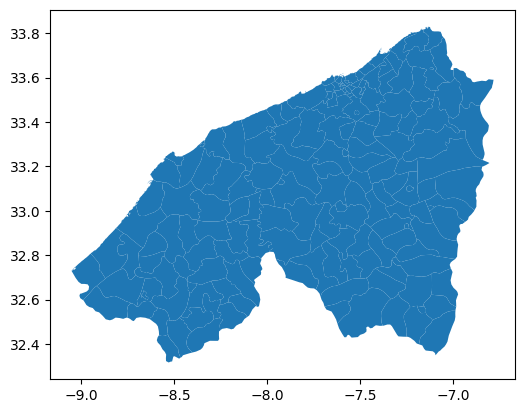

In [22]:
gdf_communes.plot()